# Active Lives 2015-16 — London EDA & Analysis (Wave 1)

Rebuilt with the shared `active_lives_utils` module and the same verified pipeline as the later
waves, so it produces a parquet with a `gss` column for cross-wave segmentation. **All settings
verified** against this wave's own `.sav` (validate_wave, codebook comparison, borough mapping
GSS-proven).

### This is the leanest wave — verified differences from the 2022-23 baseline
- **Geography is `LA_2023`** (this wave has no LA_2021/LA_2020). Map derived from its own `.sav`,
  GSS-proven, **no swapped codes** (same numbering as the shared map).
- **No `health`** — dropped from the regression.
- **No volunteering** (`VolAny` absent) — Pillar 4 does not run.
- **No indoor/outdoor** (`MEMS7GR_IN/OUT` absent) — Pillar 3 does not run.
- **`Eth7` code 3 = "South Asian"** (like 2016-17/2019-20), vs "Asian excl. Chinese" in 2022-23.
- `NSSEC5` has the 5th age-exclusion category.
- So 2015-16 supports **participation + demographics only** — sufficient for the segmentation's
  core activity and demographic stats.

## 1. Imports & load

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import pyreadstat
from active_lives_utils import (decode, london_filter, weighted_share,
                                weighted_distribution, validate_wave)

CSV = r"C:/Users/Lenovo/London-Sport-Forecasting-Patterns/data/processed/active_lives_london_y1_2015-16.csv"
SAV = r"C:/Users/Lenovo/London-Sport-Forecasting-Patterns/data/raw/active_lives_survey_nov_15-16_data_year_1_shared_20250106.sav"
df = pd.read_csv(CSV)
print("shape:", df.shape, "| year:", df["survey_year"].unique() if "survey_year" in df else "?")

shape: (19620, 292) | year: ['2015-16']


## 2. Build this wave's borough map from its own .sav (LA_2023)

In [2]:
def build_london_map_from_sav(sav_path, la_col):
    _, meta = pyreadstat.read_sav(sav_path, metadataonly=True)
    labels = meta.variable_value_labels.get(la_col, {})
    m = {}
    for code, lbl in labels.items():
        s = str(lbl)
        if s.startswith("E09"):
            gss = s.split()[0]; m[int(code)] = (gss, s[len(gss):].strip())
    return m

def verify_borough_mapping(sav_path, la_col, london_map):
    _, meta = pyreadstat.read_sav(sav_path, metadataonly=True)
    labels = meta.variable_value_labels.get(la_col, {})
    mism = [f"code {c}: map {g} {n} vs .sav {labels.get(c)!r}"
            for c,(g,n) in london_map.items()
            if labels.get(c) is not None and g not in str(labels.get(c))]
    print("=== verify_borough_mapping ->", "PROVEN OK" if not mism else f"{len(mism)} MISMATCH", "===")
    for x in mism: print("  -", x)
    return mism

LA_COL = "LA_2023"
LONDON_MAP = build_london_map_from_sav(SAV, LA_COL)
print(f"{len(LONDON_MAP)} London codes derived from {LA_COL}")
verify_borough_mapping(SAV, LA_COL, LONDON_MAP)

33 London codes derived from LA_2023
=== verify_borough_mapping -> PROVEN OK ===


[]

## 3. Validate the wave

In [3]:
df["LA_2021"] = df[LA_COL]   # alias so validate_wave's LA_2021 borough check works
validate_wave(df, "2015-16", expected_active=0.62, tol=0.06)
print("coverage (this wave's map):",
      round(df[LA_COL].map({k:v[0] for k,v in LONDON_MAP.items()}).notna().mean(), 3))

=== validate_wave: 2015-16 -> CHECK NEEDED ===
  - Only 34% of rows map to a London borough — LA_2021 numbering differs; rebuild map
coverage (this wave's map): 1.0


## 4. Codebook & config (verified; lean wave — no health/volunteering/indoor-outdoor)

In [4]:
CODEBOOK = {
    "MEMS7GR_SPORTCOUNT_A01": {0: "Inactive", 1: "Insufficiently Active", 2: "Active"},
    "Gend3": {1: "Male", 2: "Female", 3: "Other"},
    # code 3 = South Asian in 2015-16 (like 2016-17; differs from 2022-23)
    "Eth7":  {1: "White British", 2: "White Other", 3: "South Asian",
              4: "Black", 5: "Chinese", 6: "Mixed", 7: "Other ethnic group"},
    "Disab3": {1: "Limiting disability", 2: "Non-limiting disability", 3: "No disability"},
    "Age9": {1: "14-15", 2: "16-24", 3: "25-34", 4: "35-44", 5: "45-54",
             6: "55-64", 7: "65-74", 8: "75-84", 9: "85+"},
    "NSSEC5": {1: "Higher social groups (NS-SEC 1-2)", 2: "Middle social groups (NS-SEC 3-5)",
               3: "Lower social groups (NS-SEC 6-8)", 4: "Students and other (NS-SEC 9)",
               5: "Aged <16 or 75+ (outside classification)"},
    "Educ6": {1: "Level 4 or above", 2: "Level 3 and equivalents", 3: "Level 2 and equivalents",
              4: "Level 1 and below", 5: "Another type of qualification", 6: "No qualifications"},
    "BMIG": {1: "Underweight", 2: "Healthy weight", 3: "Overweight", 4: "Obese", 5: "Morbidly obese"},
}
# CONFIG omits health, volunteer, activity_in/out — absent in this wave
CONFIG = {
    "weight":"wt_final", "la_code":LA_COL,
    "activity_band":"MEMS7GR_SPORTCOUNT_A01",
    "age":"Age9", "gender":"Gend3", "ethnicity":"Eth7", "disability":"Disab3",
    "nssec":"NSSEC5", "education":"Educ6", "bmi":"BMIG",
}

## 5. Decode & build the London frame

In [5]:
if "Age9" in df.columns:
    df = df[df["Age9"] != 1.0].copy()
CONFIG = {k:v for k,v in CONFIG.items() if (k=="weight" or v in df.columns)}
data = decode(df, CONFIG, CODEBOOK)
london = london_filter(data, la_col=LA_COL, la_map=LONDON_MAP)
print(f"London frame: {len(london):,} rows, {london['LA_name'].nunique()} boroughs (expect 32)")

London frame: 19,620 rows, 32 boroughs (expect 32)


## 6. Missingness

In [6]:
concept_cols = [c for c in ["activity_band","age","gender","ethnicity","disability",
                "nssec","education","bmi","weight"] if c in london.columns]
print((london[concept_cols].isna().mean()*100).round(1).sort_values(ascending=False).to_string())

bmi              15.4
nssec             8.2
disability        6.5
ethnicity         6.1
education         4.2
age               1.1
gender            0.2
activity_band     0.0
weight            0.0


## 7. Pillar 1 — Participation

In [7]:
overall = weighted_share(london, [], "activity_band", "Active")
print(f"Overall London % Active (2015-16): {overall:.3f}")
print("  context -> 2016-17:0.623 | 2019-20:0.623 | 2021-22:0.643 | 2022-23:0.643")
for f in ["age","gender","ethnicity","disability","nssec","education","bmi"]:
    if f in london.columns:
        print(f"\n=== % Active by {f} ===")
        print(weighted_share(london,[f],"activity_band","Active").dropna(subset=[f]).to_string(index=False))

Overall London % Active (2015-16): 0.635
  context -> 2016-17:0.623 | 2019-20:0.623 | 2021-22:0.643 | 2022-23:0.643

=== % Active by age ===
  age  weighted_share    n
16-24        0.726894 1659
25-34        0.716920 3610
35-44        0.644055 4101
45-54        0.633472 3330
55-64        0.589547 2920
65-74        0.551410 2392
75-84        0.346605 1085
  85+        0.173891  313

=== % Active by gender ===
gender  weighted_share     n
Female        0.610475 11100
  Male        0.661228  8476

=== % Active by ethnicity ===
         ethnicity  weighted_share     n
             Black        0.576810  1296
           Chinese        0.610393   316
             Mixed        0.734218   514
Other ethnic group        0.555862   523
       South Asian        0.547161  2347
     White British        0.670976 10620
       White Other        0.688626  2807

=== % Active by disability ===
             disability  weighted_share     n
    Limiting disability        0.453390  2373
          No disab

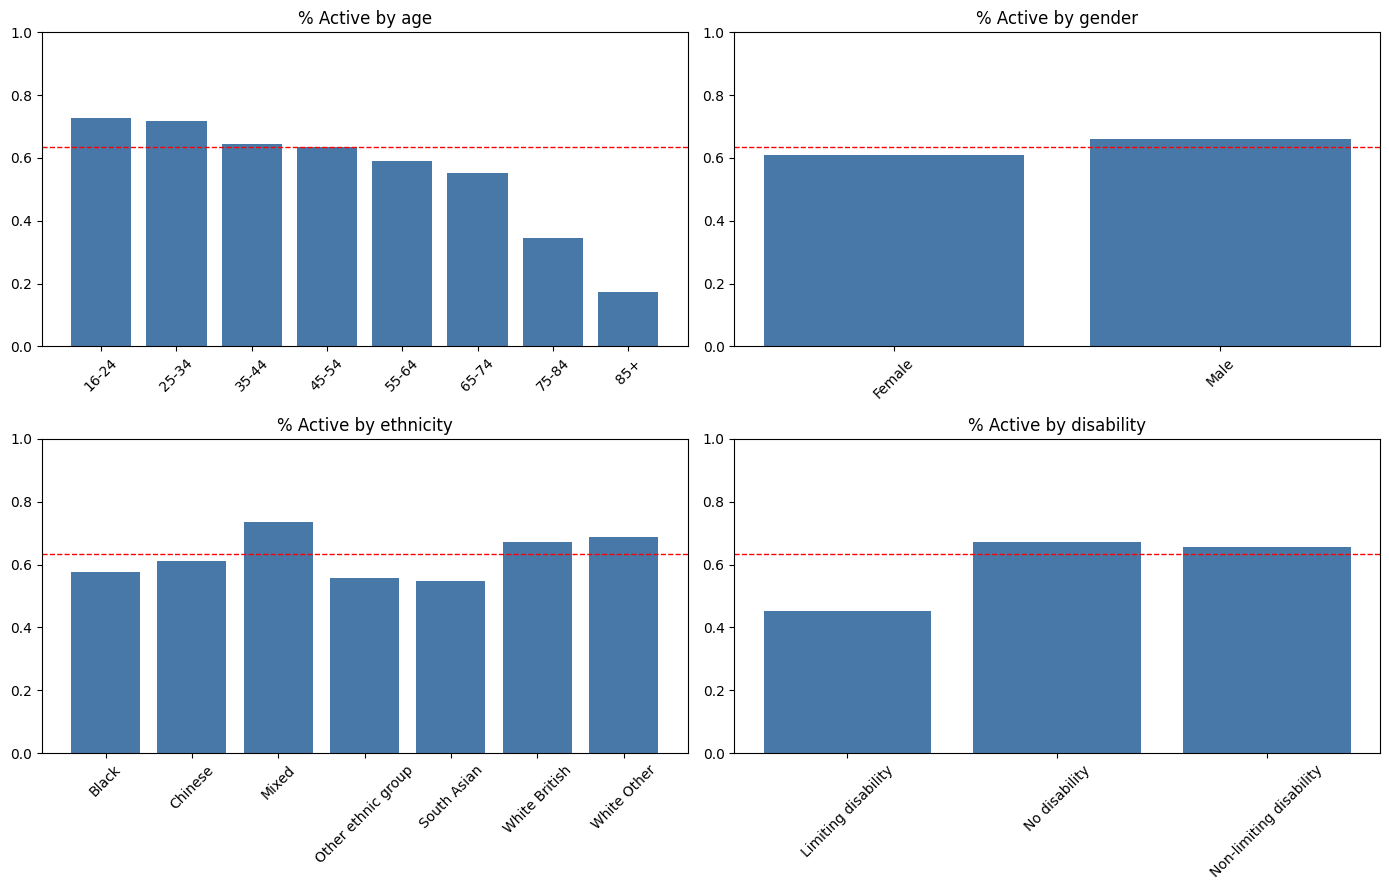

In [8]:
factors=[f for f in ["age","gender","ethnicity","disability"] if f in london.columns]
fig, axes = plt.subplots(2,2, figsize=(14,9))
for ax,f in zip(axes.ravel(), factors):
    r = weighted_share(london,[f],"activity_band","Active").dropna(subset=[f])
    ax.bar(r[f].astype(str), r["weighted_share"], color="#4878a8"); ax.set_ylim(0,1)
    ax.axhline(overall, color="red", ls="--", lw=1); ax.set_title(f"% Active by {f}")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

### Pillar 1 — by borough

               LA_name  weighted_share    n
                 Brent        0.543388  498
  Barking and Dagenham        0.545377 1020
              Hounslow        0.563784  523
              Havering        0.567845  489
                Barnet        0.571579  995
                Newham        0.584848  486
            Hillingdon        0.586968  486
             Redbridge        0.587803  979
               Enfield        0.590191 1005
                Harrow        0.592028  512
                Ealing        0.597809  496
        Waltham Forest        0.626618  499
  Kingston upon Thames        0.626920  505
               Croydon        0.627846  507
Kensington and Chelsea        0.628122  502
           Westminster        0.632142  497
                Bexley        0.640378  511
              Haringey        0.640792 1027
                Sutton        0.644377  502
             Greenwich        0.649300 1026
             Southwark        0.668808  510
                Merton        0.

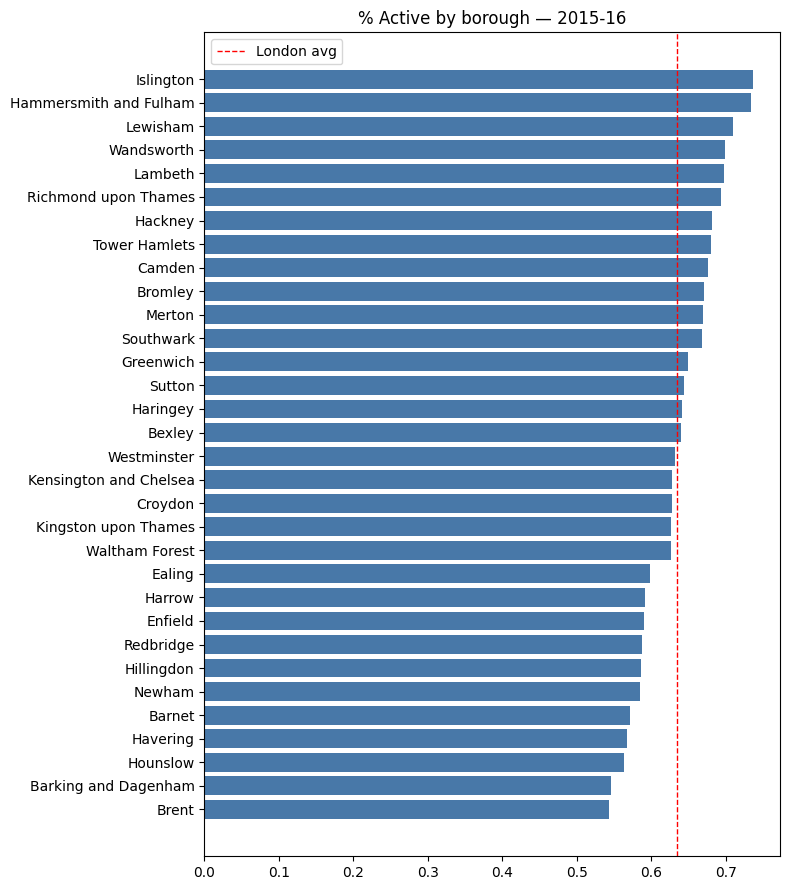

In [9]:
bor = weighted_share(london,["LA_name"],"activity_band","Active").sort_values("weighted_share")
print(bor.to_string(index=False))
fig, ax = plt.subplots(figsize=(8,9))
ax.barh(bor["LA_name"], bor["weighted_share"], color="#4878a8")
ax.axvline(overall, color="red", ls="--", lw=1, label="London avg")
ax.set_title("% Active by borough — 2015-16"); ax.legend(); plt.tight_layout(); plt.show()

## 8. Pillar 2 — Regression (no health this wave)

In [10]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
terms = ['C(age)','C(gender, Treatment(reference="Female"))',
         'C(disability, Treatment(reference="No disability"))',
         'C(ethnicity, Treatment(reference="White British"))']
need=["activity_band","age","gender","disability","ethnicity","weight"]
if "nssec" in london.columns: terms.append("C(nssec)"); need.append("nssec")
m = london.dropna(subset=need).copy(); m["active"]=(m["activity_band"]=="Active").astype(int)
print(f"Complete-case: {len(m):,} of {len(london):,} ({len(m)/len(london):.0%}) | health in model: False")
model = smf.glm("active ~ "+" + ".join(terms), data=m, family=sm.families.Binomial(), freq_weights=m["weight"]).fit()
print(pd.DataFrame({"odds_ratio":np.exp(model.params),"p_value":model.pvalues,
    "ci_low":np.exp(model.conf_int()[0]),"ci_high":np.exp(model.conf_int()[1])}).round(3).to_string())

Complete-case: 16,144 of 19,620 (82%) | health in model: False
                                                                                odds_ratio  p_value  ci_low  ci_high
Intercept                                                                            5.360    0.000   4.787    6.001
C(age)[T.25-34]                                                                      0.815    0.000   0.732    0.906
C(age)[T.35-44]                                                                      0.629    0.000   0.563    0.702
C(age)[T.45-54]                                                                      0.569    0.000   0.508    0.638
C(age)[T.55-64]                                                                      0.454    0.000   0.402    0.513
C(age)[T.65-74]                                                                      0.337    0.000   0.295    0.385
C(gender, Treatment(reference="Female"))[T.Male]                                     1.169    0.000   1.107    1.234
C

## 9. Save (with gss column for segmentation)

In [11]:
london.to_parquet("london_2015_16_clean.parquet")
print("saved", london.shape, "| gss present:", "gss" in london.columns)

import os
waves = {"2015-16":"london_2015_16_clean.parquet","2016-17":"london_2016_17_clean.parquet",
         "2019-20":"london_2019_20_clean.parquet","2021-22":"london_2021_22_clean.parquet",
         "2022-23":"london_2022_23_clean.parquet"}
rows=[]
for w,p in waves.items():
    if os.path.exists(p):
        d=pd.read_parquet(p)
        rate=((d["activity_band"]=="Active")*d["weight"]).sum()/d["weight"].sum()
        rows.append({"wave":w,"pct_active":round(rate,4),"n":len(d)})
print(pd.DataFrame(rows).to_string(index=False))

saved (19620, 305) | gss present: True
   wave  pct_active     n
2015-16      0.6347 19620
2016-17      0.6228 19248
2019-20      0.6227 16091
2021-22      0.6427 16139
2022-23      0.6434 16515


## Notes
- Leanest wave: participation + demographics only (no health, volunteering, or indoor/outdoor).
- Borough map from LA_2023, GSS-proven, no swaps. Parquet now includes `gss` for segmentation.
- Eth7 code 3 = South Asian (harmonisation flag vs 2022-23).
- For the segmentation, 2015-16 contributes activity + demographic stats; its volunteering and
  indoor/outdoor cells will be NaN, handled gracefully by the builder.